# Welcome to Colab!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

In [6]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'])
df['variety'] = iris.target_names[iris.target]
df.insert(0, 'Unnamed: 0', range(0, len(df)))
df.index = df['Unnamed: 0']
print(df.head(10))

            Unnamed: 0  sepal.length  sepal.width  petal.length  petal.width  \
Unnamed: 0                                                                     
0                    0           5.1          3.5           1.4          0.2   
1                    1           4.9          3.0           1.4          0.2   
2                    2           4.7          3.2           1.3          0.2   
3                    3           4.6          3.1           1.5          0.2   
4                    4           5.0          3.6           1.4          0.2   
5                    5           5.4          3.9           1.7          0.4   
6                    6           4.6          3.4           1.4          0.3   
7                    7           5.0          3.4           1.5          0.2   
8                    8           4.4          2.9           1.4          0.2   
9                    9           4.9          3.1           1.5          0.1   

           variety  
Unnamed: 0        

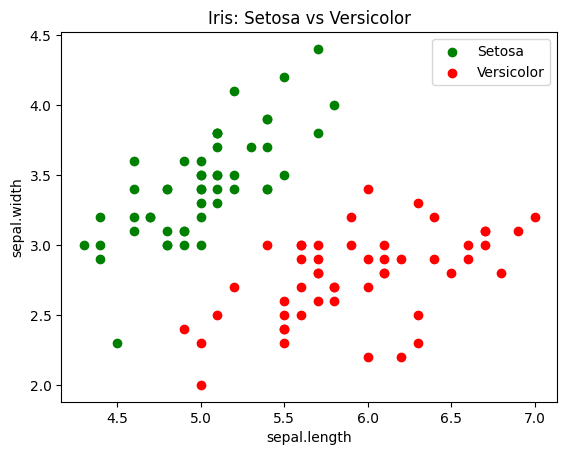

In [7]:
df.replace('setosa', '1', inplace=True)
df.replace('versicolor', '0', inplace=True)
df = df[df['variety'] != 'virginica'].copy()

df_g = df.groupby('variety')
df_1 = df_g.get_group('1')
df_0 = df_g.get_group('0')
plt.scatter(df_1['sepal.length'], df_1['sepal.width'], color='g')
plt.scatter(df_0['sepal.length'], df_0['sepal.width'], color='r')
plt.xlabel('sepal.length')
plt.ylabel('sepal.width')
plt.legend(['Setosa', 'Versicolor'])
plt.title('Iris: Setosa vs Versicolor')
plt.show()

In [13]:
X_df = df[['sepal.length', 'sepal.width']]
y = df['variety'].astype(int).values

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

print('X type:', type(X))
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Classes:', np.unique(y))

X type: <class 'numpy.ndarray'>
X shape: (100, 2)
y shape: (100,)
Classes: [0 1]


In [9]:
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X, y, epochs=40, batch_size=100, verbose=1)

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6946
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.6917
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6887
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6858
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6829
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6800
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6771
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.6742
Epoch 9/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6714
Epoch 10/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.6685
Epoch 11/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6657
Epoch 12/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.6629
Epo

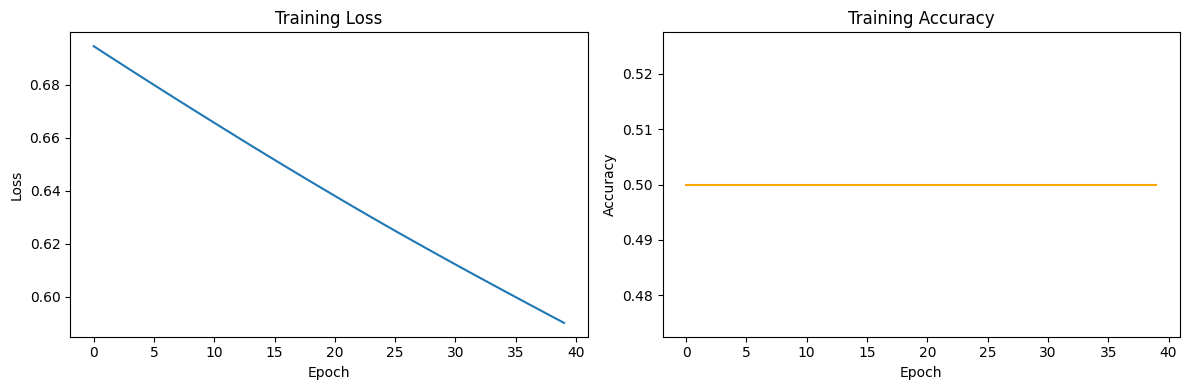

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(history.history['accuracy'], color='orange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [12]:
predictions = (model.predict(X) >= 0.5).astype(int).flatten()
accuracy = np.mean(predictions == y)

print('Predictions:', predictions)
print('Actual:     ', y)
print(f'Training Accuracy: {accuracy:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:      [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Training Accuracy: 0.5000
